In [4]:
import requests as req
from bs4 import BeautifulSoup as bs
import pandas as pd
import re # 정규표현식
url = 'https://www.weather.go.kr/w/weather/forecast/short-term.do?stnId=159'
web = req.get(url)
soup = bs(web.content , 'html.parser')
summ = soup.select('.summary')
for s in summ:
    clean_text = re.sub(r"\s+", " ", s.text)
    formatted_text = clean_text.replace("○", "\n○").replace("□", "\n□").replace("*", "\n*")
    print(formatted_text)


□ (종합) 오늘과 모레~글피 중부내륙 중심 소나기, 천둥.번개 유의
○ (오늘, 8일) 전국 대체로 흐림, 오전(11시)부터 저녁(18~21시) 사이 강원남부내륙과 강원산지, 충북북부, 경북북동산지.북부동해안, 울산.경남중.동부내륙 곳에 따라 소나기, 오전(06~12시)까지 제주도 곳에 따라 비, 강원동해안과 남부지방 곳에 따라 0.1mm 미만 빗방울
○ (내일, 9일) 전국 대체로 맑음
○ (모레, 10일) 중부지방 가끔 구름많겠고, 남부지방과 제주도 대체로 맑음, 오후(12~18시)부터 저녁(18~21시) 사이 경기북부내륙과 강원중.북부내륙.산지 곳에 따라 소나기
○ (글피, 11일) 전국 대체로 맑겠으나, 경기동부와 강원내륙.산지 오후부터 가끔 구름많겠음, 오후(12~18시)에 강원내륙.산지 곳에 따라 소나기 
* 예상 강수량(8일 오전까지)- (제주도) 제주도: 5mm 미만 
* 소나기에 의한 예상 강수량(8일)- (강원도) 강원남부내륙, 강원산지: 5~10mm- (충청권) 충북북부: 5~10mm- (경상권) 경북북동산지.북부동해안: 5~10mm/ 울산.경남중.동부내륙: 5mm 안팎 
* 소나기에 의한 예상 강수량(10일)- (수도권) 경기북부내륙: 5~20mm- (강원도) 강원중.북부내륙.산지: 5~20mm


In [5]:
import requests as req
from bs4 import BeautifulSoup as bs
import pandas as pd
import re
import os
from datetime import datetime

# --- [모듈화] 기능을 함수로 묶어 재사용 가능하게 구성 ---
def get_weather_forecast(url, headers):
    try:
        # 데이터 수집 (견고함: 예외 처리 추가)
        tables = pd.read_html(url, encoding='utf-8')
        web = req.get(url, headers=headers)
        web.raise_for_status() # 서버 응답 확인
        
        return tables[0], web.content
    except Exception as e:
        print(f"데이터 수집 중 오류 발생: {e}")
        return None, None

# 설정값
url = 'https://www.weather.go.kr/w/weather/forecast/short-term.do?stnId=159'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

# 데이터 실행
df_weather, web_content = get_weather_forecast(url, headers)

if df_weather is not None:
    # 2. 텍스트 추출 및 출력 (기존 로직 유지)
    soup = bs(web_content, 'html.parser')
    view_content = soup.select_one('.cmp-view-content')
    
    if view_content:
        for line in view_content.get_text().split('\n'):
            clean_line = re.sub(r'\s+', ' ', line).strip()
            if ('~' in clean_line) and any(k in clean_line for k in ['오늘', '내일', '모레', '기온']):
                print(clean_line.replace('○', '\n○').replace('□', '\n□'))

    # 3. 데이터 가공 (기존 로직 유지)
    df_clean = df_weather.set_index('예보요소')
    df_result = df_clean.loc[['최저기온 (℃)', '최고기온 (℃)']]
    df_transposed = df_result.T
    
    # --- [데이터 저장] 분석 결과 자동 저장 (파일 이름에 날짜 포함) ---
    save_path = f"weather_data_{datetime.now().strftime('%Y%m%d')}.csv"
    df_transposed.to_csv(save_path, encoding='utf-8-sig')
    print(f"\n[알림] 분석 데이터가 '{save_path}'로 저장되었습니다.")
    
    # 평년(오늘)행은 "오늘(x월 x일)과 똑같은 날짜였던 지난 30년간의 평균 기록범위"를 나타냄
    # 최종 결과 출력
    display(df_transposed)


□ (종합) 오늘과 모레~글피 중부내륙 중심 소나기, 천둥.번개 유의
○ (오늘, 8일) 전국 대체로 흐림,
오전(06~12시)까지 제주도 곳에 따라 비, 강원동해안과 남부지방 곳에 따라 0.1mm 미만 빗방울
○ (내일, 9일) 전국 대체로 맑음
○ (모레, 10일) 중부지방 가끔 구름많겠고, 남부지방과 제주도 대체로 맑음,

[알림] 분석 데이터가 'weather_data_20260608.csv'로 저장되었습니다.


예보요소,최저기온 (℃),최고기온 (℃)
평년(오늘),14.4 ~ 18.0,22.3 ~ 28.3
어제(07일),13.3 ~ 21.4,20.2 ~ 30.1
오늘(08일),-,20 ~ 27
내일(09일),12 ~ 18,22 ~ 30
모레(10일),12 ~ 18,23 ~ 30
글피(11일),12 ~ 18,22 ~ 29



□ (종합) 오늘과 모레~글피 중부내륙 중심 소나기, 천둥.번개 유의
○ (오늘, 8일) 전국 대체로 흐림,
오전(06~12시)까지 제주도 곳에 따라 비, 강원동해안과 남부지방 곳에 따라 0.1mm 미만 빗방울
○ (내일, 9일) 전국 대체로 맑음
○ (모레, 10일) 중부지방 가끔 구름많겠고, 남부지방과 제주도 대체로 맑음,

[알림] 분석 데이터가 'weather_data_20260608.csv'로 저장되었습니다.


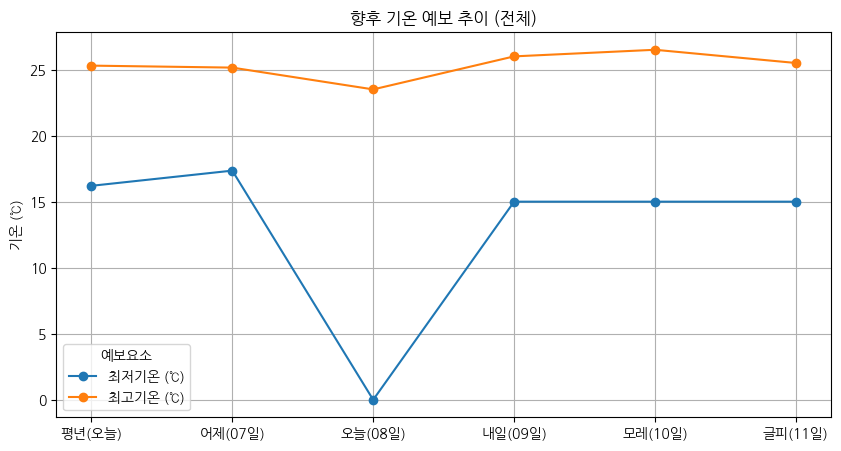

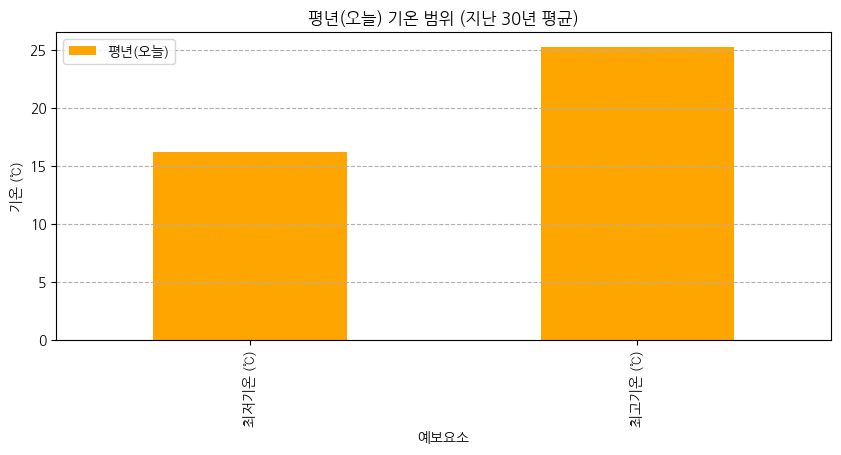

예보요소,최저기온 (℃),최고기온 (℃)
평년(오늘),14.4 ~ 18.0,22.3 ~ 28.3
어제(07일),13.3 ~ 21.4,20.2 ~ 30.1
오늘(08일),-,20 ~ 27
내일(09일),12 ~ 18,22 ~ 30
모레(10일),12 ~ 18,23 ~ 30
글피(11일),12 ~ 18,22 ~ 29


In [3]:
import requests as req
from bs4 import BeautifulSoup as bs
import pandas as pd
import re
import os
from datetime import datetime
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False 

# --- [모듈화] 데이터 수집 함수 ---
def get_weather_forecast(url, headers):
    try:
        tables = pd.read_html(url, encoding='utf-8')
        web = req.get(url, headers=headers)
        web.raise_for_status()
        return tables[0], web.content
    except Exception as e:
        print(f"데이터 수집 중 오류 발생: {e}")
        return None, None

url = 'https://www.weather.go.kr/w/weather/forecast/short-term.do?stnId=159'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

df_weather, web_content = get_weather_forecast(url, headers)

if df_weather is not None:
    # 2. 텍스트 추출 및 출력
    soup = bs(web_content, 'html.parser')
    view_content = soup.select_one('.cmp-view-content')
    if view_content:
        for line in view_content.get_text().split('\n'):
            clean_line = re.sub(r'\s+', ' ', line).strip()
            if ('~' in clean_line) and any(k in clean_line for k in ['오늘', '내일', '모레', '기온']):
                print(clean_line.replace('○', '\n○').replace('□', '\n□'))

    # 3. 데이터 가공
    df_clean = df_weather.set_index('예보요소')
    df_result = df_clean.loc[['최저기온 (℃)', '최고기온 (℃)']]
    df_transposed = df_result.T
    
    # 4. 데이터 저장
    save_path = f"weather_data_{datetime.now().strftime('%Y%m%d')}.csv"
    df_transposed.to_csv(save_path, encoding='utf-8-sig')
    print(f"\n[알림] 분석 데이터가 '{save_path}'로 저장되었습니다.")
    
    # --- [데이터 전처리 함수] ---
    def clean_and_convert(val):
        val = str(val).strip()
        if val == '-' or val == '': return 0.0
        if '~' in val:
            nums = [float(n) for n in val.split('~')]
            return sum(nums) / len(nums)
        return float(val)

    df_processed = df_transposed.map(clean_and_convert)
    
    # --- [시각화 1] 전체 데이터 그래프 ---
    df_processed.plot(kind='line', marker='o', figsize=(10, 5))
    plt.title('향후 기온 예보 추이 (전체)')
    plt.ylabel('기온 (℃)')
    plt.grid(True)
    plt.show()

    # --- [시각화 2] 평년 데이터만 별도 그래프 ---
    # 평년 데이터 행만 추출
    if '평년(오늘)' in df_processed.index:
        df_normal = df_processed.loc[['평년(오늘)']]
        df_normal.T.plot(kind='bar', color='orange', figsize=(10, 4))
        plt.title('평년(오늘) 기온 범위 (지난 30년 평균)')
        plt.ylabel('기온 (℃)')
        plt.grid(axis='y', linestyle='--')
        plt.show()

    # 최종 결과 출력
    display(df_transposed)